In [1]:
import sys
sys.path.insert(0, '..')

import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as sp_stats

from src.metrics.bistability import analyse_bistability
from src.metrics.self_reinforcement import extract_runs

BASE     = Path('..') / 'results' / 'mas' / 'final_dataset'
W_VALUES = [1, 2, 5]
TOPOS    = ['fc', 'star']
DATASETS = ['gpqa', 'hiddenbench']

W_COLORS  = {1: '#4C72B0', 2: '#DD8452', 5: '#55A868'}
DS_COLORS = {'gpqa': '#5470C6', 'hiddenbench': '#EE6666'}
T_COLORS  = {'fc': '#2c7bb6', 'star': '#d7191c'}
DS_LABELS = {'gpqa': 'GPQA', 'hiddenbench': 'HiddenBench'}
T_LABELS  = {'fc': 'Full-connected', 'star': 'Star'}
LABEL_COLORS = {'monostable': '#4C72B0', 'multistable': "#DB1D1D",
                'stochastic': "#F3EA44", 'insufficient': '#aaaaaa'}

/Users/I550854/Documents/Master Thesis/self-organization-mas/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Data & Run Bistability Analysis

For each of the 420 (task, config) cells: run `analyse_bistability` on its 30 repetitions. Also compute per-cell SR mean slope for the cross-motif section.

In [2]:
cell_rows  = []
comp_cache = {}   # keyed by (ds, topo, W, qid) — stores visit counts + rep detail

t0 = time.time()

for f in sorted(BASE.glob('**/*.json')):
    d    = json.loads(f.read_text())
    W    = d['W']
    ds   = d['dataset']
    topo = d.get('topology_name', 'fc')
    qid  = d['question_id']
    gt   = d['ground_truth']
    reps = d['repetitions']
    opts = tuple(d['options'].keys())

    r = analyse_bistability(reps, seed=42)

    dom_att     = max(r['p_hat'], key=r['p_hat'].get) if r['p_hat'] else None
    p_dom       = r['p_hat'].get(dom_att, float('nan'))
    dom_correct = (dom_att == gt) if isinstance(dom_att, str) else float('nan')

    runs        = extract_runs(reps)
    slopes      = [x['slope'] for x in runs]
    mean_slope  = float(np.mean(slopes)) if slopes else float('nan')
    p_sr        = float(np.mean(np.array(slopes) > 0)) if slopes else float('nan')

    accuracy = float(np.mean([rep['correct'] for rep in reps]))

    # D0: inverse Simpson diversity of round-0 vote composition across reps
    init_counts = {}
    for rep in reps:
        comp0 = tuple(rep['trajectory'][0]['phase_b'][i]['vote'] for i in range(len(rep['trajectory'][0]['phase_b'])))
        init_counts[comp0] = init_counts.get(comp0, 0) + 1
    d0 = 1.0 / sum((v/len(reps))**2 for v in init_counts.values())


    ci_lo, ci_hi = r['n_eff_ci']
    cell_rows.append({
        'dataset': ds, 'topology': topo, 'W': W, 'qid': qid, 'ground_truth': gt,
        'M': r['M'],
        'n_reps': r['n_reps'], 'n_converged': r['n_converged'], 'n_excluded': r['n_excluded'],
        'n_eff': r['n_eff'], 'n_eff_ci_lo': ci_lo, 'n_eff_ci_hi': ci_hi,
        'cramers_v': r['cramers_v'], 'p_basin': r['p_basin'],
        'label': r['label'], 'degree': r['degree'],
        'dom_attractor': str(dom_att), 'p_dominant': p_dom,
        'dom_correct': dom_correct,
        'mean_sr_slope': mean_slope, 'p_sr': p_sr,
        'accuracy': accuracy, 'd0': d0,
    })

    N_agents = reps[0]['N']
    counts = {}
    for rep in reps:
        for rd in rep['trajectory']:
            votes = [ag['vote'] for ag in rd['phase_b']]
            comp  = tuple(votes.count(o) for o in opts)
            counts[comp] = counts.get(comp, 0) + 1
    comp_cache[(ds, topo, W, qid)] = {
        'counts': counts, 'label': r['label'],
        'reps_detail': r['reps'], 'ground_truth': gt,
        'opts': opts, 'N': N_agents,
    }

elapsed = time.time() - t0
df = pd.DataFrame(cell_rows)
print(f'Done in {elapsed:.1f}s  |  cells: {len(df)}')
print()
print(df['label'].value_counts().to_string())


Done in 23.0s  |  cells: 420

label
stochastic     284
monostable      74
multistable     62


---
## Part 1 — Accounting Funnel

In [3]:
print('=== CONVERGENCE ACCOUNTING ===')
print(f'Total repetitions : {df["n_reps"].sum():,}')
print(f'Converged (k>=3)  : {df["n_converged"].sum():,}'
      f'  ({100*df["n_converged"].sum()/df["n_reps"].sum():.2f}%)')
print(f'Excluded (k<3)    : {df["n_excluded"].sum():,}'
      f'  ({100*df["n_excluded"].sum()/df["n_reps"].sum():.2f}%)')
print(f'Cells with n_c<2  : {(df["n_converged"]<2).sum()}')
print()

# per-dataset label breakdown
tab = df.groupby(['dataset','label']).size().unstack(fill_value=0)
for col in ['monostable','multistable','stochastic','insufficient']:
    if col not in tab.columns: tab[col] = 0
print(tab[['monostable','multistable','stochastic','insufficient']].to_string())
print()

# per-config
grp = df.groupby(['dataset','topology','W','label']).size().unstack(fill_value=0).reset_index()
for col in ['monostable','multistable','stochastic','insufficient']:
    if col not in grp.columns: grp[col] = 0
print(grp[['dataset','topology','W','monostable','multistable','stochastic','insufficient']].to_string(index=False))

=== CONVERGENCE ACCOUNTING ===
Total repetitions : 12,600
Converged (k>=3)  : 12,301  (97.63%)
Excluded (k<3)    : 299  (2.37%)
Cells with n_c<2  : 0

label        monostable  multistable  stochastic  insufficient
dataset                                                       
gpqa                 58           41         111             0
hiddenbench          16           21         173             0

    dataset topology  W  monostable  multistable  stochastic  insufficient
       gpqa       fc  1          11           11          13             0
       gpqa       fc  2           7            6          22             0
       gpqa       fc  5          10            7          18             0
       gpqa     star  1          11            5          19             0
       gpqa     star  2          12            7          16             0
       gpqa     star  5           7            5          23             0
hiddenbench       fc  1           3            5          27           

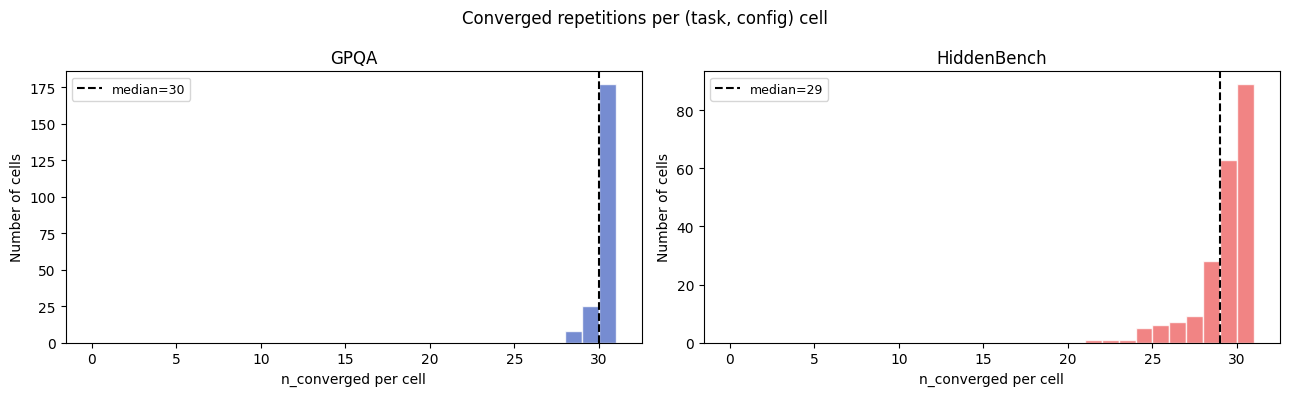

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, ds in zip(axes, DATASETS):
    sub = df[df['dataset']==ds]
    ax.hist(sub['n_converged'], bins=range(0, 32),
            color=DS_COLORS[ds], edgecolor='white', alpha=0.8)
    ax.axvline(sub['n_converged'].median(), color='black', linestyle='--',
               linewidth=1.5, label=f'median={sub["n_converged"].median():.0f}')
    ax.set_xlabel('n_converged per cell')
    ax.set_ylabel('Number of cells')
    ax.set_title(DS_LABELS[ds])
    ax.legend(fontsize=9)
fig.suptitle('Converged repetitions per (task, config) cell', fontsize=12)
plt.tight_layout(); plt.show()

---
## Part 2 — Prevalence

Distributions of $N_{\mathrm{eff}}$ and Cramér's $V$. Fraction of cells where dominant attractor is the correct option.

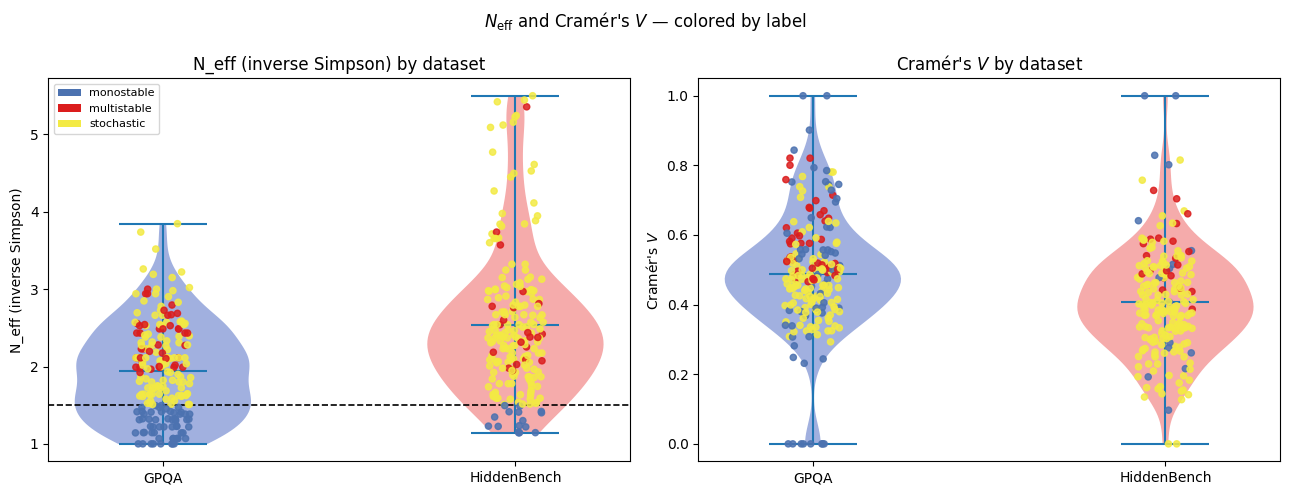

=== Summary statistics ===
GPQA          n=210
  n_eff      : mean=1.944  median=1.927  max=3.846
  cramers_v  : mean=0.489  median=0.482  max=1.000

HiddenBench   n=210
  n_eff      : mean=2.536  median=2.378  max=5.500
  cramers_v  : mean=0.407  median=0.401  max=1.000



In [5]:
from matplotlib.patches import Patch

valid = df[df['label'] != 'insufficient'].copy()
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, ylabel in zip(axes,
        ['n_eff', 'cramers_v'],
        ['N_eff (inverse Simpson)', "Cramér's $V$"]):
    data = [valid[valid['dataset']==ds][col].dropna().values for ds in DATASETS]
    parts = ax.violinplot(data, positions=[1,2], widths=0.5,
                          showmeans=True, showmedians=False)
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(list(DS_COLORS.values())[i])
        pc.set_alpha(0.55)
    for i, ds in enumerate(DATASETS):
        vals = valid[valid['dataset']==ds][col].dropna()
        lbls = valid[valid['dataset']==ds]['label']
        jitter = np.random.default_rng(42).uniform(-0.08, 0.08, len(vals))
        c = [LABEL_COLORS.get(lbl, '#aaaaaa') for lbl in lbls]
        ax.scatter(i+1+jitter, vals, s=20, c=c, alpha=0.85, zorder=3)
    if col == 'n_eff':
        ax.axhline(1.5, color='black', linestyle='--', lw=1.2, label='threshold 1.5')
    ax.set_xticks([1,2]); ax.set_xticklabels([DS_LABELS[ds] for ds in DATASETS])
    ax.set_ylabel(ylabel); ax.set_title(f'{ylabel} by dataset')

handles = [Patch(facecolor=LABEL_COLORS[l], label=l)
           for l in ['monostable','multistable','stochastic']]
axes[0].legend(handles=handles, fontsize=8)
fig.suptitle("$N_{\mathrm{eff}}$ and Cramér's $V$ — colored by label", fontsize=12)
plt.tight_layout(); plt.show()

print('=== Summary statistics ===')
for ds in DATASETS:
    sub = valid[valid['dataset']==ds]
    print(f'{DS_LABELS[ds]:12s}  n={len(sub)}')
    for col in ['n_eff','cramers_v']:
        s = sub[col].dropna()
        print(f'  {col:11s}: mean={s.mean():.3f}  median={s.median():.3f}  max={s.max():.3f}')
    print()

In [6]:
print('=== Dominant attractor == correct option ===')
valid2 = df[(df['label']!='insufficient')&(df['n_converged']>=2)].copy()
valid2['dom_correct_bool'] = valid2['dom_correct'].apply(
    lambda x: bool(x) if x==x else None)

for ds in DATASETS:
    sub = valid2[valid2['dataset']==ds].dropna(subset=['dom_correct_bool'])
    frac = sub['dom_correct_bool'].mean()
    print(f'  {DS_LABELS[ds]:12s}: {frac:.3f}  ({int(sub["dom_correct_bool"].sum())}/{len(sub)})')
print()
for lbl in ['monostable','multistable','stochastic']:
    sub = valid2[valid2['label']==lbl].dropna(subset=['dom_correct_bool'])
    if len(sub)==0: continue
    frac = sub['dom_correct_bool'].mean()
    print(f'  {lbl:14s}: {frac:.3f}  ({int(sub["dom_correct_bool"].sum())}/{len(sub)})')

=== Dominant attractor == correct option ===
  GPQA        : 0.548  (115/210)
  HiddenBench : 0.328  (67/204)

  monostable    : 0.527  (39/74)
  multistable   : 0.435  (27/62)
  stochastic    : 0.417  (116/278)


---
## Part 3 — Axis Effects

Topology (fc/star) and $W$ effects on $N_{\mathrm{eff}}$ and $V$. All comparisons are within (dataset, W) or within (dataset, topology).

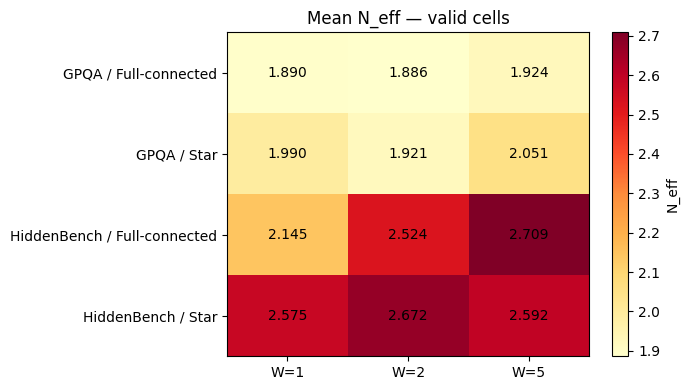

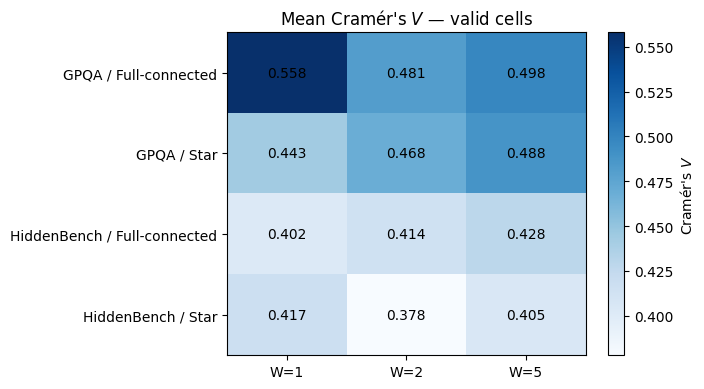

In [7]:
valid = df[df['label'] != 'insufficient'].copy()

for col, cmap, label in [
    ('n_eff',     'YlOrRd', 'N_eff'),
    ('cramers_v', 'Blues',  "Cramér's $V$"),
]:
    pivot = valid.groupby(['dataset','topology','W'])[col].mean().unstack('W').round(3)
    fig, ax = plt.subplots(figsize=(7, 4))
    vals = pivot.values.astype(float)
    im = ax.imshow(vals, aspect='auto', cmap=cmap,
                   vmin=np.nanmin(vals), vmax=max(np.nanmax(vals), 0.01))
    ax.set_xticks(range(len(W_VALUES))); ax.set_xticklabels([f'W={w}' for w in W_VALUES])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f'{DS_LABELS.get(ds,ds)} / {T_LABELS.get(t,t)}'
                        for ds,t in pivot.index])
    for i in range(len(pivot.index)):
        for j in range(len(W_VALUES)):
            ax.text(j, i, f'{vals[i,j]:.3f}', ha='center', va='center', fontsize=10)
    plt.colorbar(im, ax=ax, label=label)
    ax.set_title(f'Mean {label} — valid cells')
    plt.tight_layout(); plt.show()

In [8]:
print('=== Topology comparison (fc vs star) ===')
for ds in DATASETS:
    print(DS_LABELS[ds])
    for w in W_VALUES:
        for col in ['n_eff','cramers_v']:
            fc   = valid[(valid['dataset']==ds)&(valid['topology']=='fc')  &(valid['W']==w)][col].dropna()
            star = valid[(valid['dataset']==ds)&(valid['topology']=='star')&(valid['W']==w)][col].dropna()
            if len(fc)<2 or len(star)<2: continue
            stat, p = sp_stats.mannwhitneyu(fc, star, alternative='two-sided')
            print(f'  W={w} {col:11s}: fc={fc.mean():.3f}  star={star.mean():.3f}  p={p:.4f}')
    print()

print('=== W effect (Kruskal-Wallis) ===')
for ds in DATASETS:
    for topo in TOPOS:
        for col in ['n_eff','cramers_v']:
            groups = [valid[(valid['dataset']==ds)&(valid['topology']==topo)&(valid['W']==w)][col].dropna().values
                      for w in W_VALUES]
            if any(len(g)<2 for g in groups): continue
            stat, p = sp_stats.kruskal(*groups)
            print(f'  {DS_LABELS[ds]:12s} {topo:5s} {col:11s}: H={stat:.3f}  p={p:.4f}')

=== Topology comparison (fc vs star) ===
GPQA
  W=1 n_eff      : fc=1.890  star=1.990  p=0.5181
  W=1 cramers_v  : fc=0.558  star=0.443  p=0.0065
  W=2 n_eff      : fc=1.886  star=1.921  p=0.9719
  W=2 cramers_v  : fc=0.481  star=0.468  p=0.5491
  W=5 n_eff      : fc=1.924  star=2.051  p=0.3180
  W=5 cramers_v  : fc=0.498  star=0.488  p=0.4593

HiddenBench
  W=1 n_eff      : fc=2.145  star=2.575  p=0.0289
  W=1 cramers_v  : fc=0.402  star=0.417  p=0.3534
  W=2 n_eff      : fc=2.524  star=2.672  p=0.4109
  W=2 cramers_v  : fc=0.414  star=0.378  p=0.3238
  W=5 n_eff      : fc=2.709  star=2.592  p=0.8097
  W=5 cramers_v  : fc=0.428  star=0.405  p=0.1196

=== W effect (Kruskal-Wallis) ===
  GPQA         fc    n_eff      : H=0.007  p=0.9964
  GPQA         fc    cramers_v  : H=4.194  p=0.1228
  GPQA         star  n_eff      : H=1.049  p=0.5919
  GPQA         star  cramers_v  : H=0.493  p=0.7817
  HiddenBench  fc    n_eff      : H=5.989  p=0.0501
  HiddenBench  fc    cramers_v  : H=1.476  p=0

---
## Part 4 — Cross-Motif Analysis

**SR × Bistability**: multistable cells — does SR slope stay elevated? (SR amplifies initial basin selection and locks it in.)

**Non-convergence × Bistability**: excluded (non-converged) reps are the same sequences that feed the LC analysis. Do they cluster in specific label groups?

In [9]:
for col in ['mean_sr_slope', 'p_sr']:
    print(f'=== {col} by label ===')
    for lbl in ['monostable','multistable','stochastic']:
        sub = df[df['label']==lbl][col].dropna()
        if len(sub)==0: print(f'  {lbl:14s}: no cells'); continue
        print(f'  {lbl:14s}: mean={sub.mean():.3f}  median={sub.median():.3f}  n={len(sub)}')
    print()

mono = df[df['label']=='monostable']['mean_sr_slope'].dropna()
stoc = df[df['label']=='stochastic']['mean_sr_slope'].dropna()
mult = df[df['label']=='multistable']['mean_sr_slope'].dropna()
print('=== MWU: mean_sr_slope across labels ===')
for a_lbl, a_v, b_lbl, b_v in [
    ('monostable', mono, 'stochastic', stoc),
    ('monostable', mono, 'multistable', mult),
    ('stochastic', stoc, 'multistable', mult),
]:
    if len(a_v)<2 or len(b_v)<2: continue
    stat, p = sp_stats.mannwhitneyu(a_v, b_v, alternative='two-sided')
    print(f'  {a_lbl} vs {b_lbl}: p={p:.4f}  ({a_v.mean():.3f} vs {b_v.mean():.3f})')

=== mean_sr_slope by label ===
  monostable    : mean=0.553  median=0.537  n=74
  multistable   : mean=0.422  median=0.412  n=62
  stochastic    : mean=0.391  median=0.387  n=284

=== p_sr by label ===
  monostable    : mean=0.860  median=0.863  n=74
  multistable   : mean=0.789  median=0.807  n=62
  stochastic    : mean=0.798  median=0.809  n=284

=== MWU: mean_sr_slope across labels ===
  monostable vs stochastic: p=0.0000  (0.553 vs 0.391)
  monostable vs multistable: p=0.0000  (0.553 vs 0.422)
  stochastic vs multistable: p=0.0175  (0.391 vs 0.422)


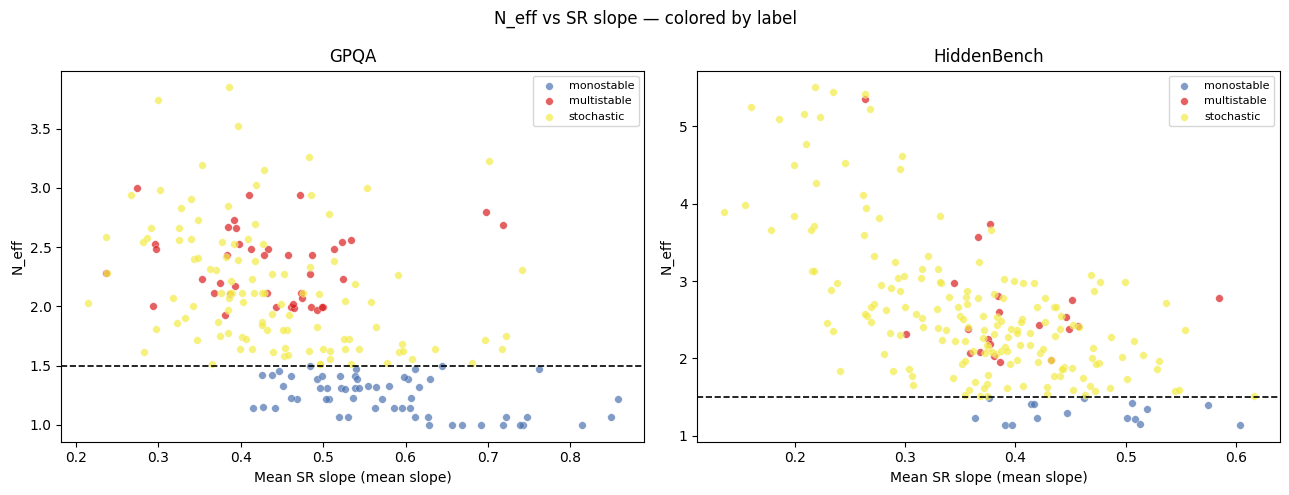

=== Spearman: N_eff vs mean_sr_slope ===
  GPQA        : rho=-0.587  p=0.0000  n=210
  HiddenBench : rho=-0.586  p=0.0000  n=210


In [10]:
valid = df[df['label']!='insufficient'].copy()
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, ds in zip(axes, DATASETS):
    sub = valid[valid['dataset']==ds]
    for lbl in ['monostable','multistable','stochastic']:
        s = sub[sub['label']==lbl]
        ax.scatter(s['mean_sr_slope'], s['n_eff'],
                   color=LABEL_COLORS[lbl], s=30, alpha=0.7,
                   label=lbl, edgecolors='white', linewidths=0.3)
    ax.axhline(1.5, color='black', linestyle='--', lw=1.2)
    ax.set_xlabel('Mean SR slope (mean slope)')
    ax.set_ylabel('N_eff')
    ax.set_title(DS_LABELS[ds])
    ax.legend(fontsize=8)
fig.suptitle('N_eff vs SR slope — colored by label', fontsize=12)
plt.tight_layout(); plt.show()

print('=== Spearman: N_eff vs mean_sr_slope ===')
for ds in DATASETS:
    sub = valid[valid['dataset']==ds].dropna(subset=['n_eff','mean_sr_slope'])
    r, p = sp_stats.spearmanr(sub['n_eff'], sub['mean_sr_slope'])
    print(f'  {DS_LABELS[ds]:12s}: rho={r:.3f}  p={p:.4f}  n={len(sub)}')

In [11]:
print('=== Non-convergence rate by bistability label ===')
for lbl in ['monostable','multistable','stochastic','insufficient']:
    sub = df[df['label']==lbl]
    if len(sub)==0: continue
    n_ex  = sub['n_excluded'].sum()
    n_tot = sub['n_reps'].sum()
    p_ex  = n_ex/n_tot if n_tot>0 else float('nan')
    print(f'  {lbl:14s}: cells={len(sub):3d}  excluded={n_ex:4d}/{n_tot}  ({100*p_ex:.1f}%)')

=== Non-convergence rate by bistability label ===
  monostable    : cells= 74  excluded=  17/2220  (0.8%)
  multistable   : cells= 62  excluded=  27/1860  (1.5%)
  stochastic    : cells=284  excluded= 255/8520  (3.0%)


---
## Part 5 — Energy Landscape

Empirical potential $U(s)=-\ln\hat{P}(s)$ over observed composition states. Local minima (all single-flip neighbors have higher $U$) are attractors. Shown for multistable cells; falls back to highest-$N_{\mathrm{eff}}$ cells if none flagged.

Multistable cells: 62 — showing first 4


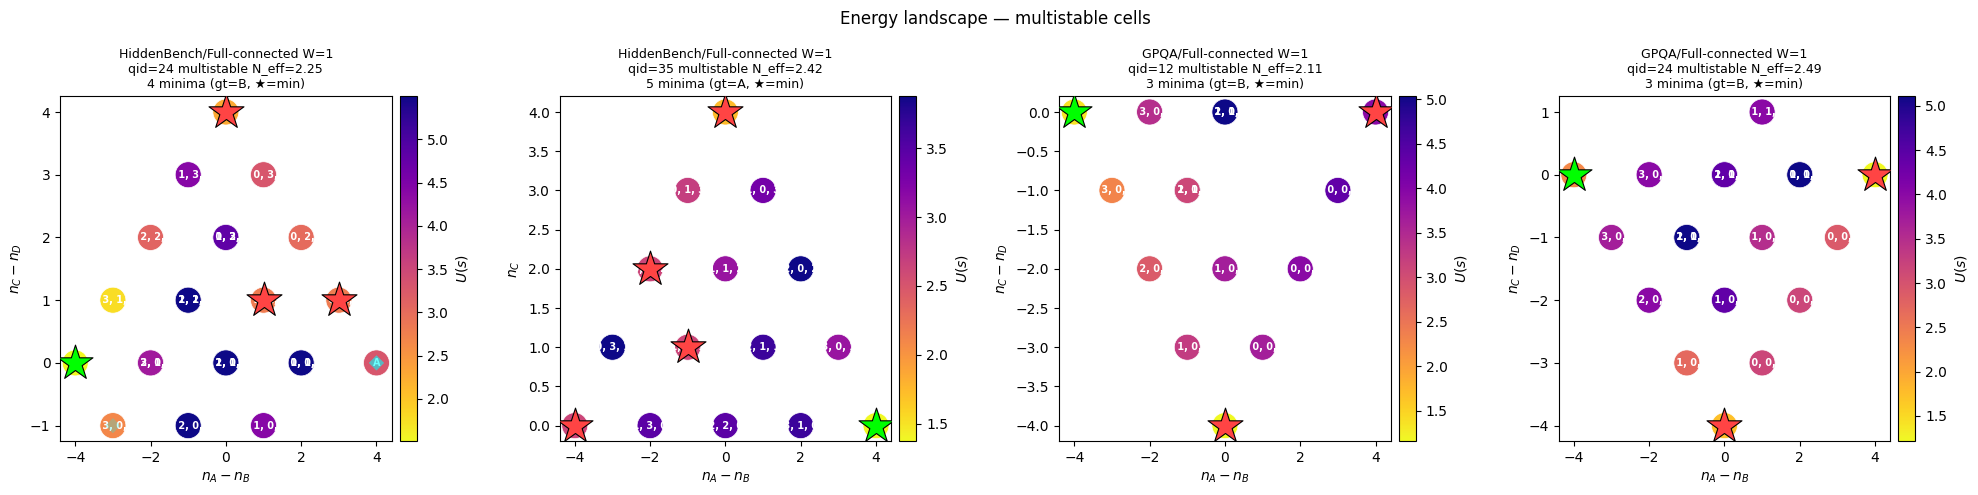

In [12]:
def _single_flip_neighbors(comp):
    neighbors = []
    for i in range(len(comp)):
        for j in range(len(comp)):
            if i==j or comp[i]==0: continue
            new = list(comp); new[i]-=1; new[j]+=1
            neighbors.append(tuple(new))
    return neighbors

def energy_landscape(counts):
    total = sum(counts.values())
    U = {s: -np.log(v/total) for s,v in counts.items() if v>0}
    minima = []
    for s, u_s in U.items():
        nbrs = [nb for nb in _single_flip_neighbors(s) if nb in U]
        if nbrs and all(U[nb]>=u_s for nb in nbrs):
            minima.append((s, u_s))
    return U, sorted(minima, key=lambda x: x[1])

def plot_landscape(counts, reps_detail, gt, opts, N, title, ax):
    if not counts:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        return
    M = len(opts)
    U, minima = energy_landscape(counts)

    # project: x = n[0]-n[1], y = n[2]-n[3] for M=4; x = n[0]-n[1], y = n[2] for M=3
    def _xy(s):
        x = s[0] - s[1]
        y = (s[2] - s[3]) if M == 4 else s[2]
        return x, y

    xs = [_xy(s)[0] for s in U]
    ys = [_xy(s)[1] for s in U]
    us = list(U.values())
    sc = ax.scatter(xs, ys, c=us, cmap='plasma_r', s=350,
                    edgecolors='white', lw=0.5, zorder=2)
    plt.colorbar(sc, ax=ax, label='$U(s)$', pad=0.02)

    for s, u_s in U.items():
        # label: option letter if unanimous, else raw tuple
        lbl = opts[list(s).index(N)] if max(s) == N else str(s)
        xi, yi = _xy(s)
        ax.text(xi, yi, lbl, ha='center', va='center',
                fontsize=7, color='white', fontweight='bold')

    for s, u_s in minima:
        correct = isinstance(s, tuple) and max(s) == N and opts[list(s).index(N)] == gt
        mc = '#00ff00' if correct else '#ff4444'
        xi, yi = _xy(s)
        ax.scatter(xi, yi, marker='*', s=700,
                   color=mc, edgecolors='black', lw=0.8, zorder=4)

    # endpoint cloud
    for ri in [r for r in reps_detail if r['converged']]:
        att = ri['attractor']
        if isinstance(att, str) and att in opts:
            idx = opts.index(att)
            sf = tuple(N if i == idx else 0 for i in range(M))
        elif isinstance(att, tuple) and len(att) == M:
            sf = att
        else:
            continue
        xi, yi = _xy(sf)
        ax.scatter(xi, yi, marker='D', s=60,
                   color='cyan', alpha=0.25, edgecolors='none', zorder=3)

    xlabel = f'$n_{{{opts[0]}}} - n_{{{opts[1]}}}$'
    ylabel = (f'$n_{{{opts[2]}}} - n_{{{opts[3]}}}$' if M == 4
              else f'$n_{{{opts[2]}}}$')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(f'{title}\n{len(minima)} minima (gt={gt}, ★=min)', fontsize=9)

multi_cells = [(k, v) for k,v in comp_cache.items() if v['label']=='multistable']
fallback    = len(multi_cells)==0
if fallback:
    print('No multistable cells — showing 4 cells with highest N_eff')
    top4 = df.nlargest(4, 'n_eff')
    target = [(tuple(row[['dataset','topology','W','qid']]),
               comp_cache[tuple(row[['dataset','topology','W','qid']])])
              for _, row in top4.iterrows()
              if tuple(row[['dataset','topology','W','qid']]) in comp_cache]
else:
    target = multi_cells[:4]
    print(f'Multistable cells: {len(multi_cells)} — showing first 4')

n = len(target)
if n>0:
    fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
    if n==1: axes=[axes]
    for ax, (key, info) in zip(axes, target):
        ds, topo, W, qid = key
        row = df[(df['dataset']==ds)&(df['topology']==topo)&
                 (df['W']==W)&(df['qid']==qid)]
        if len(row)==0: continue
        row = row.iloc[0]
        t = (f'{DS_LABELS[ds]}/{T_LABELS[topo]} W={W}\n'
             f'qid={qid} {row["label"]} N_eff={row["n_eff"]:.2f}')
        plot_landscape(info['counts'], info['reps_detail'], info['ground_truth'],
                       info['opts'], info['N'], t, ax)
    tag = 'multistable' if not fallback else 'highest-N_eff'
    fig.suptitle(f'Energy landscape — {tag} cells', fontsize=12)
    plt.tight_layout(); plt.show()


---
## Part 6 — Robustness

Sensitivity of label counts to the $N_{\mathrm{eff}}$ threshold and the $n_c$ floor.

In [13]:
thresholds = [1.25, 1.5, 1.75, 2.0]
print('=== Sensitivity to N_eff threshold (n_c floor = 2) ===')
print(f'  {"thresh":>8s}  {"mono":>8s}  {"multi":>8s}  {"stoch":>8s}')
for thresh in thresholds:
    n_mono=n_multi=n_stoc=0
    for _, row in df.iterrows():
        if row['n_converged']<2 or row['n_eff']!=row['n_eff']: continue
        ne, pb, ci = row['n_eff'], row['p_basin'], row['n_eff_ci_lo']
        if ne<thresh: n_mono+=1
        elif pb<0.05 and ci>=thresh: n_multi+=1
        else: n_stoc+=1
    print(f'  {thresh:>8.2f}  {n_mono:>8d}  {n_multi:>8d}  {n_stoc:>8d}')
print()

floors = [2, 5, 10, 15]
print('=== Sensitivity to n_c floor (threshold = 1.5) ===')
print(f'  {"floor":>6s}  {"valid":>6s}  {"insuff":>6s}  {"mono":>6s}  {"multi":>6s}  {"stoch":>6s}')
for floor in floors:
    n_ins=n_mono=n_multi=n_stoc=0
    for _, row in df.iterrows():
        nc, ne, pb, ci = row['n_converged'], row['n_eff'], row['p_basin'], row['n_eff_ci_lo']
        if nc<floor or ne!=ne: n_ins+=1
        elif ne<1.5: n_mono+=1
        elif pb<0.05 and ci>=1.5: n_multi+=1
        else: n_stoc+=1
    print(f'  {floor:>6d}  {420-n_ins:>6d}  {n_ins:>6d}  {n_mono:>6d}  {n_multi:>6d}  {n_stoc:>6d}')
print()

print('=== n_c per dataset ===')
for ds in DATASETS:
    sub = df[df['dataset']==ds]['n_converged']
    print(f'  {DS_LABELS[ds]:12s}: min={sub.min()}  median={sub.median():.0f}'
          f'  n_c<10: {(sub<10).sum()}  n_c<5: {(sub<5).sum()}')

=== Sensitivity to N_eff threshold (n_c floor = 2) ===
    thresh      mono     multi     stoch
      1.25        38        80       302
      1.50        74        62       284
      1.75       129        30       261
      2.00       176        11       233

=== Sensitivity to n_c floor (threshold = 1.5) ===
   floor   valid  insuff    mono   multi   stoch
       2     420       0      74      62     284
       5     420       0      74      62     284
      10     420       0      74      62     284
      15     420       0      74      62     284

=== n_c per dataset ===
  GPQA        : min=28  median=30  n_c<10: 0  n_c<5: 0
  HiddenBench : min=21  median=29  n_c<10: 0  n_c<5: 0


---
## Part 7 — Accuracy Correlation

Does multistability predict lower accuracy? Correlate $N_{\mathrm{eff}}$ and $V$ with per-task accuracy, conditioned on dataset.

In [14]:
# Task-level: N_eff / V vs accuracy, per dataset
print('=== Spearman: N_eff / V vs accuracy (valid cells, per dataset) ===')
valid = df[df['label'] != 'insufficient'].copy()
for ds in DATASETS:
    sub = valid[valid['dataset']==ds].dropna(subset=['n_eff','cramers_v','accuracy'])
    r1, p1 = sp_stats.spearmanr(sub['n_eff'],     sub['accuracy'])
    r2, p2 = sp_stats.spearmanr(sub['cramers_v'], sub['accuracy'])
    print(f'  {DS_LABELS[ds]:12s}  N_eff vs acc: rho={r1:.3f}  p={p1:.4f}  |'
          f'  V vs acc: rho={r2:.3f}  p={p2:.4f}  (n={len(sub)})')
print()

# By label: mean accuracy
print('=== Mean accuracy by label ===')
for lbl in ['monostable','multistable','stochastic']:
    sub = df[df['label']==lbl]['accuracy'].dropna()
    if len(sub)==0: continue
    print(f'  {lbl:14s}: mean={sub.mean():.3f}  median={sub.median():.3f}  n={len(sub)}')
print()

# MWU: monostable vs multistable accuracy
for ds in DATASETS:
    mono_acc = df[(df['label']=='monostable')&(df['dataset']==ds)]['accuracy'].dropna()
    mult_acc = df[(df['label']=='multistable')&(df['dataset']==ds)]['accuracy'].dropna()
    stoc_acc = df[(df['label']=='stochastic') &(df['dataset']==ds)]['accuracy'].dropna()
    print(f'{DS_LABELS[ds]}')
    for a_lbl, a_v in [('monostable',mono_acc),('multistable',mult_acc),('stochastic',stoc_acc)]:
        print(f'  {a_lbl:14s}: mean={a_v.mean():.3f}  n={len(a_v)}')
    for a_lbl, a_v, b_lbl, b_v in [
        ('mono', mono_acc, 'vs multi', mult_acc),
        ('mono', mono_acc, 'vs stoch', stoc_acc),
        ('multi', mult_acc, 'vs stoch', stoc_acc),
    ]:
        if len(a_v)<2 or len(b_v)<2: continue
        stat, p = sp_stats.mannwhitneyu(a_v, b_v, alternative='two-sided')
        print(f'    {b_lbl}: p={p:.4f}')
    print()


=== Spearman: N_eff / V vs accuracy (valid cells, per dataset) ===
  GPQA          N_eff vs acc: rho=-0.393  p=0.0000  |  V vs acc: rho=0.144  p=0.0370  (n=210)
  HiddenBench   N_eff vs acc: rho=0.161  p=0.0194  |  V vs acc: rho=0.024  p=0.7343  (n=210)

=== Mean accuracy by label ===
  monostable    : mean=0.507  median=0.800  n=74
  multistable   : mean=0.387  median=0.433  n=62
  stochastic    : mean=0.381  median=0.367  n=284

GPQA
  monostable    : mean=0.597  n=58
  multistable   : mean=0.401  n=41
  stochastic    : mean=0.469  n=111
    vs multi: p=0.0113
    vs stoch: p=0.0010
    vs stoch: p=0.0751

HiddenBench
  monostable    : mean=0.181  n=16
  multistable   : mean=0.359  n=21
  stochastic    : mean=0.324  n=173
    vs multi: p=0.0090
    vs stoch: p=0.0004
    vs stoch: p=0.4606



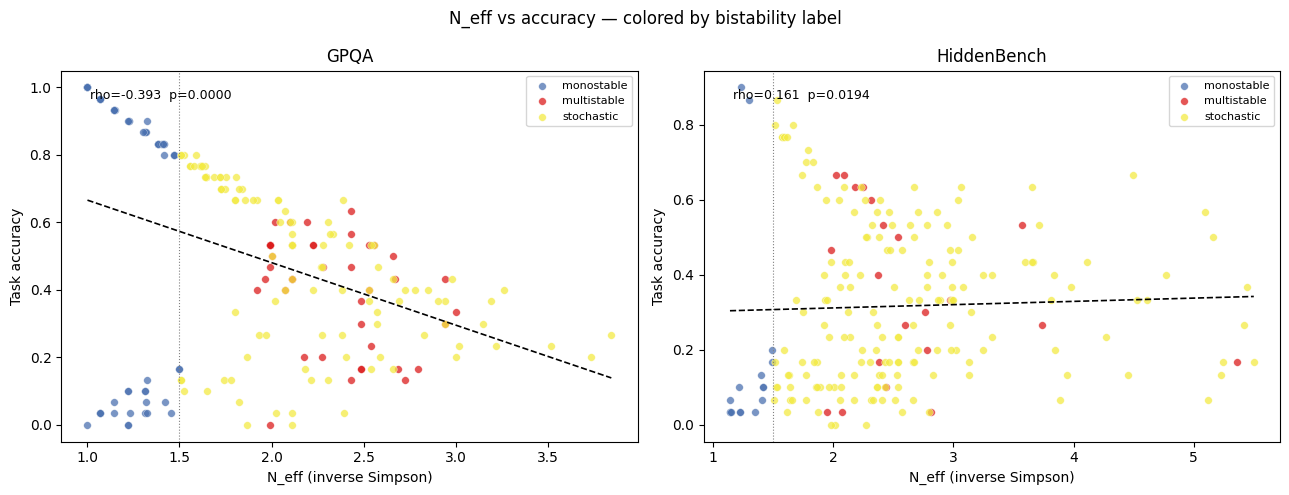

In [15]:
# Scatter: N_eff vs accuracy, faceted by dataset, colored by label
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, ds in zip(axes, DATASETS):
    sub = valid[valid['dataset']==ds].dropna(subset=['n_eff','accuracy'])
    for lbl in ['monostable','multistable','stochastic']:
        s = sub[sub['label']==lbl]
        ax.scatter(s['n_eff'], s['accuracy'],
                   color=LABEL_COLORS[lbl], s=30, alpha=0.75,
                   label=lbl, edgecolors='white', linewidths=0.3)
    s_all = sub
    rho, p = sp_stats.spearmanr(s_all['n_eff'], s_all['accuracy'])
    m, b   = np.polyfit(s_all['n_eff'], s_all['accuracy'], 1)
    xs = np.linspace(s_all['n_eff'].min(), s_all['n_eff'].max(), 50)
    ax.plot(xs, m*xs+b, color='black', lw=1.2, linestyle='--')
    ax.text(0.05, 0.95, f'rho={rho:.3f}  p={p:.4f}',
            transform=ax.transAxes, fontsize=9, va='top')
    ax.axvline(1.5, color='grey', lw=0.8, linestyle=':')
    ax.set_xlabel('N_eff (inverse Simpson)')
    ax.set_ylabel('Task accuracy')
    ax.set_title(DS_LABELS[ds])
    ax.legend(fontsize=8)
fig.suptitle('N_eff vs accuracy — colored by bistability label', fontsize=12)
plt.tight_layout(); plt.show()


---
## Part 8 — Initial-Diversity Control

Is $N_{\mathrm{eff}}$ just tracking round-0 vote diversity $D_0$? Partial out $D_0$ to check basins are structural, not mechanical.

In [16]:
# D0 vs N_eff: how correlated are they?
print('=== Spearman: D0 vs N_eff (valid cells, per dataset) ===')
valid = df[df['label'] != 'insufficient'].copy()
for ds in DATASETS:
    sub = valid[valid['dataset']==ds].dropna(subset=['d0','n_eff'])
    r, p = sp_stats.spearmanr(sub['d0'], sub['n_eff'])
    print(f'  {DS_LABELS[ds]:12s}: rho={r:.3f}  p={p:.4f}  n={len(sub)}')
print()

# Partial correlation: N_eff ~ accuracy after removing linear effect of D0
# Using partial Spearman via residuals of rank regression
from scipy.stats import rankdata

print('=== Partial Spearman: N_eff vs accuracy | D0 (per dataset) ===')
for ds in DATASETS:
    sub = valid[valid['dataset']==ds].dropna(subset=['d0','n_eff','accuracy'])
    if len(sub) < 5: continue
    rn = rankdata(sub['n_eff'].values).astype(float)
    rd = rankdata(sub['d0'].values).astype(float)
    ra = rankdata(sub['accuracy'].values).astype(float)
    # residualise N_eff ranks on D0 ranks
    slope, intercept = np.polyfit(rd, rn, 1)
    rn_res = rn - (slope*rd + intercept)
    # residualise accuracy ranks on D0 ranks
    slope2, intercept2 = np.polyfit(rd, ra, 1)
    ra_res = ra - (slope2*rd + intercept2)
    r_partial, p_partial = sp_stats.pearsonr(rn_res, ra_res)
    r_raw, p_raw = sp_stats.spearmanr(sub['n_eff'], sub['accuracy'])
    print(f'  {DS_LABELS[ds]:12s}: raw rho={r_raw:.3f} (p={p_raw:.4f})  '
          f'partial rho={r_partial:.3f} (p={p_partial:.4f})')
print()

# D0 vs label
print('=== Mean D0 by label ===')
for lbl in ['monostable','multistable','stochastic']:
    sub = df[df['label']==lbl]['d0'].dropna()
    if len(sub)==0: continue
    print(f'  {lbl:14s}: mean={sub.mean():.3f}  median={sub.median():.3f}')
print()

# MWU: D0 by label
mono_d0 = df[df['label']=='monostable']['d0'].dropna()
mult_d0 = df[df['label']=='multistable']['d0'].dropna()
stoc_d0 = df[df['label']=='stochastic']['d0'].dropna()
print('=== MWU: D0 across labels ===')
for a_lbl, a_v, b_lbl, b_v in [
    ('mono', mono_d0, 'stoch',  stoc_d0),
    ('mono', mono_d0, 'multi',  mult_d0),
    ('stoch',stoc_d0, 'multi',  mult_d0),
]:
    if len(a_v)<2 or len(b_v)<2: continue
    stat, p = sp_stats.mannwhitneyu(a_v, b_v, alternative='two-sided')
    print(f'  {a_lbl} vs {b_lbl}: p={p:.4f}  ({a_v.mean():.3f} vs {b_v.mean():.3f})')


=== Spearman: D0 vs N_eff (valid cells, per dataset) ===
  GPQA        : rho=0.738  p=0.0000  n=210
  HiddenBench : rho=0.148  p=0.0315  n=210

=== Partial Spearman: N_eff vs accuracy | D0 (per dataset) ===
  GPQA        : raw rho=-0.393 (p=0.0000)  partial rho=-0.309 (p=0.0000)
  HiddenBench : raw rho=0.161 (p=0.0194)  partial rho=0.156 (p=0.0242)

=== Mean D0 by label ===
  monostable    : mean=7.051  median=5.441
  multistable   : mean=13.564  median=13.849
  stochastic    : mean=9.327  median=5.733

=== MWU: D0 across labels ===
  mono vs stoch: p=0.0167  (7.051 vs 9.327)
  mono vs multi: p=0.0000  (7.051 vs 13.564)
  stoch vs multi: p=0.0001  (9.327 vs 13.564)


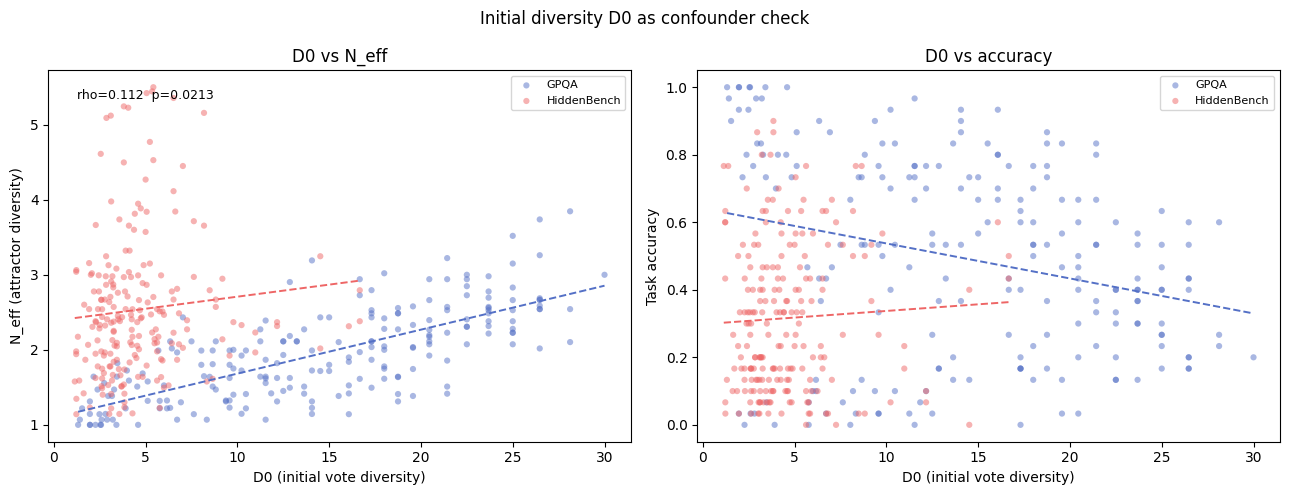

In [17]:
# Scatter matrix: D0 vs N_eff, D0 vs accuracy, colored by dataset
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

valid = df[df['label'] != 'insufficient'].copy()

ax = axes[0]
for ds in DATASETS:
    sub = valid[valid['dataset']==ds].dropna(subset=['d0','n_eff'])
    ax.scatter(sub['d0'], sub['n_eff'],
               color=DS_COLORS[ds], s=20, alpha=0.5,
               label=DS_LABELS[ds], edgecolors='none')
for ds in DATASETS:
    sub = valid[valid['dataset']==ds].dropna(subset=['d0','n_eff'])
    m, b = np.polyfit(sub['d0'], sub['n_eff'], 1)
    xs = np.linspace(sub['d0'].min(), sub['d0'].max(), 50)
    ax.plot(xs, m*xs+b, color=DS_COLORS[ds], lw=1.4, linestyle='--')
rho, p = sp_stats.spearmanr(valid['d0'].dropna(), valid['n_eff'].dropna())
ax.text(0.05, 0.95, f'rho={rho:.3f}  p={p:.4f}', transform=ax.transAxes, fontsize=9, va='top')
ax.set_xlabel('D0 (initial vote diversity)')
ax.set_ylabel('N_eff (attractor diversity)')
ax.set_title('D0 vs N_eff')
ax.legend(fontsize=8)

ax = axes[1]
for ds in DATASETS:
    sub = valid[valid['dataset']==ds].dropna(subset=['d0','accuracy'])
    ax.scatter(sub['d0'], sub['accuracy'],
               color=DS_COLORS[ds], s=20, alpha=0.5,
               label=DS_LABELS[ds], edgecolors='none')
for ds in DATASETS:
    sub = valid[valid['dataset']==ds].dropna(subset=['d0','accuracy'])
    m, b = np.polyfit(sub['d0'], sub['accuracy'], 1)
    xs = np.linspace(sub['d0'].min(), sub['d0'].max(), 50)
    ax.plot(xs, m*xs+b, color=DS_COLORS[ds], lw=1.4, linestyle='--')
ax.set_xlabel('D0 (initial vote diversity)')
ax.set_ylabel('Task accuracy')
ax.set_title('D0 vs accuracy')
ax.legend(fontsize=8)

fig.suptitle('Initial diversity D0 as confounder check', fontsize=12)
plt.tight_layout(); plt.show()


---
## Summary & Findings

In [18]:
print('=== BISTABILITY ANALYSIS — SUMMARY ===')
print()
lc = df['label'].value_counts()
for lbl in ['monostable','multistable','stochastic','insufficient']:
    n = lc.get(lbl,0)
    print(f'  {lbl:14s}: {n:3d} / {len(df)}  ({100*n/len(df):.1f}%)')
print()
valid = df[df['label']!='insufficient']
print(f'Valid cells: {len(valid)}')
print(f'  N_eff mean  : {valid["n_eff"].mean():.3f}')
print(f'  N_eff median: {valid["n_eff"].median():.3f}')
print(f'  N_eff > 1.5 : {(valid["n_eff"]>1.5).sum()} cells')
print(f'  V mean      : {valid["cramers_v"].mean():.3f}')
print()
for ds in DATASETS:
    sub = df[df['dataset']==ds]
    lc2 = sub['label'].value_counts()
    sub_v = sub[sub['label']!='insufficient']
    print(f'{DS_LABELS[ds]}')
    for lbl in ['monostable','multistable','stochastic','insufficient']:
        print(f'  {lbl:14s}: {lc2.get(lbl,0)}')
    if len(sub_v):
        n_dc = sub_v['dom_correct'].sum()
        print(f'  N_eff mean  : {sub_v["n_eff"].mean():.3f}')
        print(f'  Dom correct : {n_dc:.0f}/{len(sub_v)} ({100*n_dc/len(sub_v):.1f}%)')
    print()

=== BISTABILITY ANALYSIS — SUMMARY ===

  monostable    :  74 / 420  (17.6%)
  multistable   :  62 / 420  (14.8%)
  stochastic    : 284 / 420  (67.6%)
  insufficient  :   0 / 420  (0.0%)

Valid cells: 420
  N_eff mean  : 2.240
  N_eff median: 2.113
  N_eff > 1.5 : 346 cells
  V mean      : 0.448

GPQA
  monostable    : 58
  multistable   : 41
  stochastic    : 111
  insufficient  : 0
  N_eff mean  : 1.944
  Dom correct : 115/210 (54.8%)

HiddenBench
  monostable    : 16
  multistable   : 21
  stochastic    : 173
  insufficient  : 0
  N_eff mean  : 2.536
  Dom correct : 67/210 (31.9%)

